In [84]:
import os
import shutil

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import xgboost

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
import mlflow

import joblib

In [85]:
# download_path = kagglehub.dataset_download("ruchi798/data-science-job-salaries")

# target_path = "../data"
# os.makedirs(target_path, exist_ok=True)




In [96]:
# shutil.copytree(download_path, target_path, dirs_exist_ok=True)
df = pd.read_csv("../data/ds_salaries.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.drop(columns=["salary"], inplace=True)
df.drop(columns=["salary_currency"], inplace=True)
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [87]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary_in_usd       607 non-null    int64 
 5   employee_residence  607 non-null    object
 6   remote_ratio        607 non-null    int64 
 7   company_location    607 non-null    object
 8   company_size        607 non-null    object
dtypes: int64(3), object(6)
memory usage: 42.8+ KB


In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,607.0,2021.405272,0.692133,2020.0,2021.0,2022.0,2022.0,2022.0
salary_in_usd,607.0,112297.869852,70957.259411,2859.0,62726.0,101570.0,150000.0,600000.0
remote_ratio,607.0,70.922570,40.709130,0.0,50.0,100.0,100.0,100.0


In [97]:
df.rename(columns={"salary_in_usd": "target_salary_in_usd"}, inplace=True)
df.head()

,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [90]:
df.isna().sum()

work_year               0
experience_level        0
employment_type         0
job_title               0
target_salary_in_usd    0
employee_residence      0
remote_ratio            0
company_location        0
company_size            0
dtype: int64

In [91]:
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")
print(f"Dataset rows: {len(df)}")
print(f"Duplicate percentage: {dup_count / len(df) * 100:.2f}%")

Exact duplicate rows: 42
Dataset rows: 607
Duplicate percentage: 6.92%


In [98]:
skew = df.skew(numeric_only=True).sort_values(ascending=False)
print("Feature skewness (sorted):\n")
print(skew.round(3))

Feature skewness (sorted):

target_salary_in_usd    1.668
work_year              -0.736
remote_ratio           -0.904
dtype: float64


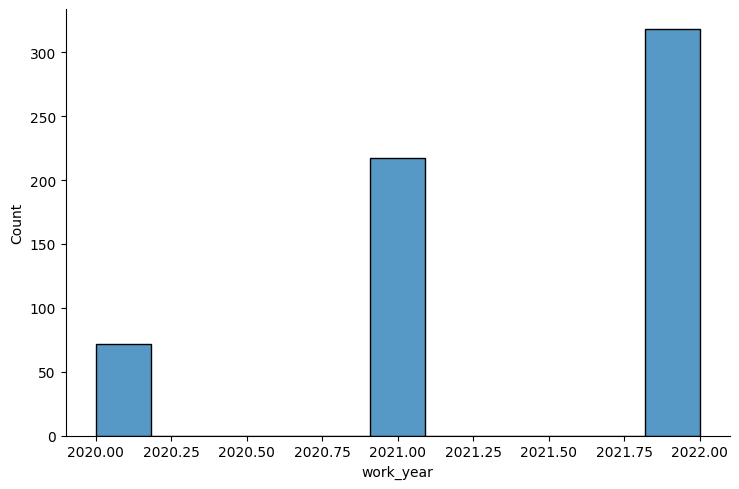

In [99]:
sns.displot(x=df['work_year'],aspect=1.5)

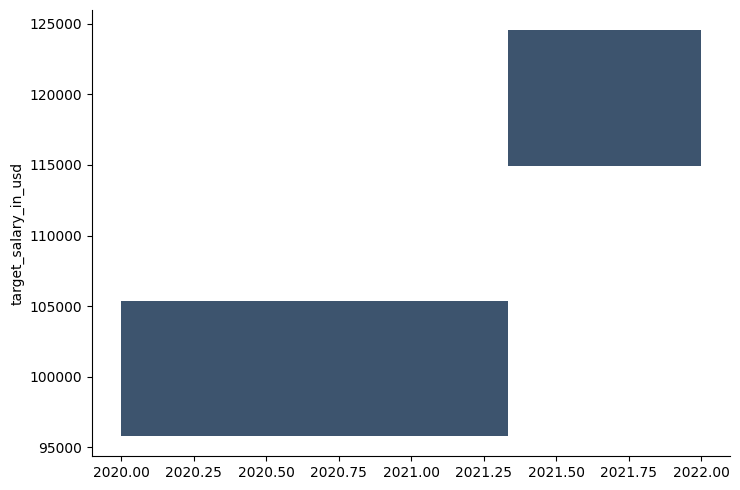

In [100]:
years=[2022,2021,2020]
salaries_mean_year=df.groupby(["work_year"]).target_salary_in_usd.mean().sort_values(ascending=False)
sns.displot(x=years,y=salaries_mean_year,aspect=1.5)

In [107]:
data =df.groupby("job_title").target_salary_in_usd.mean().sort_values(ascending=False).head(10)

C:\Users\pro\AppData\Local\Temp\ipykernel_2104\3373025498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job_title', y='target_salary_in_usd', data=pd.DataFrame(data), order=data.index, palette='Set2', showfliers=False, width=0.6)
C:\Users\pro\AppData\Local\Temp\ipykernel_2104\3373025498.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='work_year', y='target_salary_in_usd', data=df, ci=None)


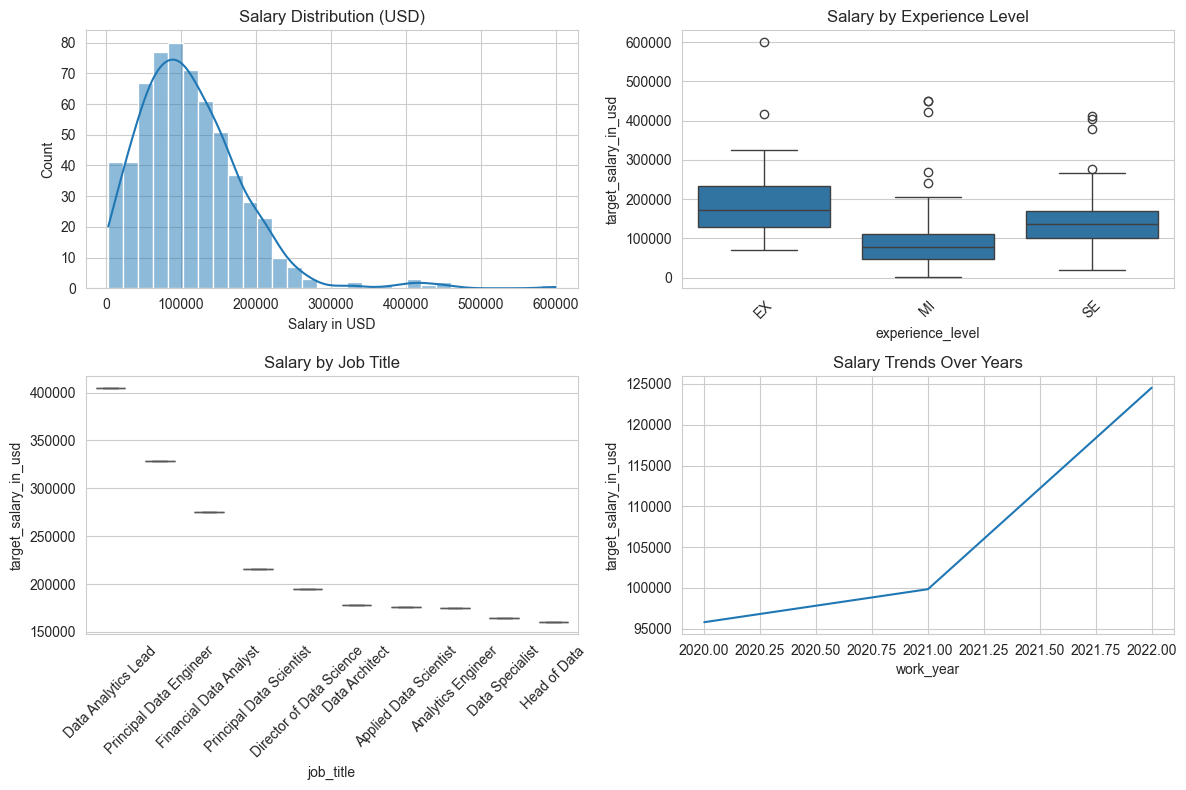

In [111]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['target_salary_in_usd'], kde=True, bins=30)
plt.title('Salary Distribution (USD)')
plt.xlabel('Salary in USD')

plt.subplot(2, 2, 2)
sns.boxplot(x='experience_level', y='target_salary_in_usd', data=df, order=['EX', 'MI', 'SE', 'EX'])
plt.title('Salary by Experience Level')
plt.xticks(rotation=45)


plt.subplot(2, 2, 3)
sns.boxplot(x='job_title', y='target_salary_in_usd', data=pd.DataFrame(data), order=data.index, palette='Set2', showfliers=False, width=0.6)
plt.title('Salary by Job Title')
plt.xticks(rotation=45)


plt.subplot(2, 2, 4)
sns.lineplot(x='work_year', y='target_salary_in_usd', data=df, ci=None)
plt.title('Salary Trends Over Years')

plt.tight_layout()
chart_path = "../charts/salary_analysis.png"
plt.savefig(chart_path)
plt.show()

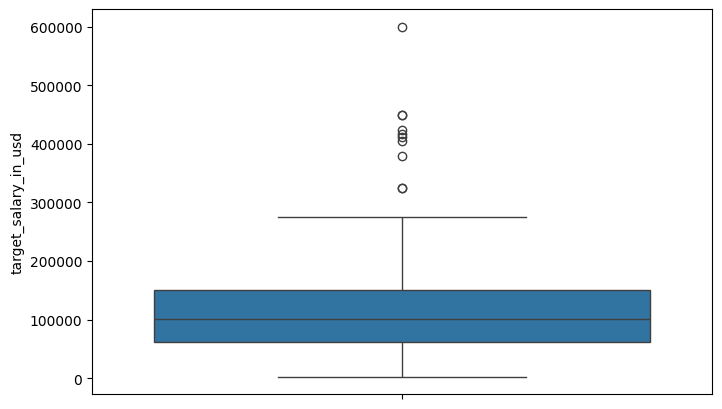

In [101]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['target_salary_in_usd'])
plt.show()


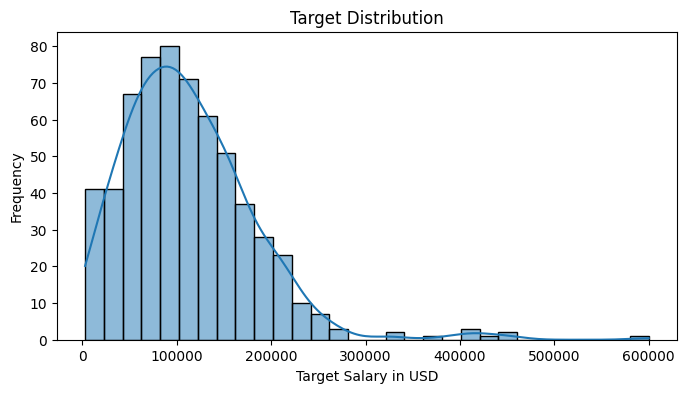

In [102]:
plt.figure(figsize=(8, 4))
sns.histplot(df['target_salary_in_usd'], bins=30, kde=True)
plt.title('Target Distribution')
plt.xlabel('Target Salary in USD')
plt.ylabel('Frequency')
chart_path = "../charts/target_distribution.png"
plt.savefig(chart_path)
plt.show()

In [61]:
mapping = {"EN": 0, "SE": 1, "MI": 2, "EX": 3}
df["experience_level"] = df["experience_level"].map(mapping)
df.head()

,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,2,FT,Data Scientist,79833,DE,0,DE,L
1,2020,1,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,1,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,2,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,1,FT,Machine Learning Engineer,150000,US,50,US,L


In [62]:
mapping = { "FL": 0,"PT": 1, "FT": 2, "CT": 3}
df["employment_type"] = df["employment_type"].map(mapping)
df.head()


,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,2,2,Data Scientist,79833,DE,0,DE,L
1,2020,1,2,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,1,2,Big Data Engineer,109024,GB,50,GB,M
3,2020,2,2,Product Data Analyst,20000,HN,0,HN,S
4,2020,1,2,Machine Learning Engineer,150000,US,50,US,L


In [63]:

df["remote_ratio"] = df["remote_ratio"].replace({0: 0, 50: 2, 100: 3})
df.head()

,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,2,2,Data Scientist,79833,DE,0,DE,L
1,2020,1,2,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,1,2,Big Data Engineer,109024,GB,2,GB,M
3,2020,2,2,Product Data Analyst,20000,HN,0,HN,S
4,2020,1,2,Machine Learning Engineer,150000,US,2,US,L


In [64]:
df['same_copuntry'] = (df['company_location'] == df['employee_residence']).astype(int)
df.head(100)

,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size,same_copuntry
0,2020,2,2,Data Scientist,79833,DE,0,DE,L,1
1,2020,1,2,Machine Learning Scientist,260000,JP,0,JP,S,1
2,2020,1,2,Big Data Engineer,109024,GB,2,GB,M,1
3,2020,2,2,Product Data Analyst,20000,HN,0,HN,S,1
4,2020,1,2,Machine Learning Engineer,150000,US,2,US,L,1
...,...,...,...,...,...,...,...,...,...,...
95,2021,2,2,Cloud Data Engineer,89294,SG,2,SG,L,1
96,2021,0,1,AI Scientist,12000,BR,3,US,S,0
97,2021,2,2,Financial Data Analyst,450000,US,3,US,L,1
98,2021,0,2,Computer Vision Software Engineer,70000,US,3,US,M,1


In [65]:
df['target_salary_in_usd']= np.log1p(df['target_salary_in_usd'])

In [66]:
df.groupby("job_title")["target_salary_in_usd"].mean().sort_values(ascending=False)

job_title
Data Analytics Lead                         12.911645
Principal Data Engineer                     12.546294
Financial Data Analyst                      12.264970
Principal Data Scientist                    12.214844
Director of Data Science                    12.131991
Analytics Engineer                          12.061078
Data Architect                              12.055639
Data Specialist                             12.013707
Director of Data Engineering                11.922717
Data Science Manager                        11.908424
Applied Data Scientist                      11.881117
Head of Data Science                        11.827262
Head of Data                                11.772739
Data Analytics Manager                      11.744535
Lead Data Engineer                          11.734062
Machine Learning Scientist                  11.719279
Cloud Data Engineer                         11.691318
Machine Learning Manager                    11.670826
Data Engineering M

In [67]:


encoder=LabelEncoder()
# df["job_title"]=encoder.fit_transform(df["job_title"])
# df.head()

In [68]:
mapping = {"S": 0, "M": 1, "L": 2, "X": 3}
df["company_size"] = df["company_size"].map(mapping)    

In [69]:
all_locations = pd.concat([df["employee_residence"], df["company_location"]])

encoder.fit(all_locations)

df["employee_residence"] = encoder.transform(df["employee_residence"])
df["company_location"] = encoder.transform(df["company_location"])

df.head()

,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size,same_copuntry
0,2020,2,2,Data Scientist,11.287705,15,0,15,2,1
1,2020,1,2,Machine Learning Scientist,12.468441,34,0,34,0,1
2,2020,1,2,Big Data Engineer,11.599332,21,2,21,1,1
3,2020,2,2,Product Data Analyst,9.903538,24,0,24,0,1
4,2020,1,2,Machine Learning Engineer,11.918397,57,2,57,2,1


In [70]:
corr = df.corr(numeric_only=True)
corr[['target_salary_in_usd']].sort_values(by='target_salary_in_usd', ascending=False)

,target_salary_in_usd
target_salary_in_usd,1.000000
employee_residence,0.421191
company_location,0.410025
work_year,0.262747
employment_type,0.220616
same_copuntry,0.170260
company_size,0.152967
remote_ratio,0.117656
experience_level,0.106789


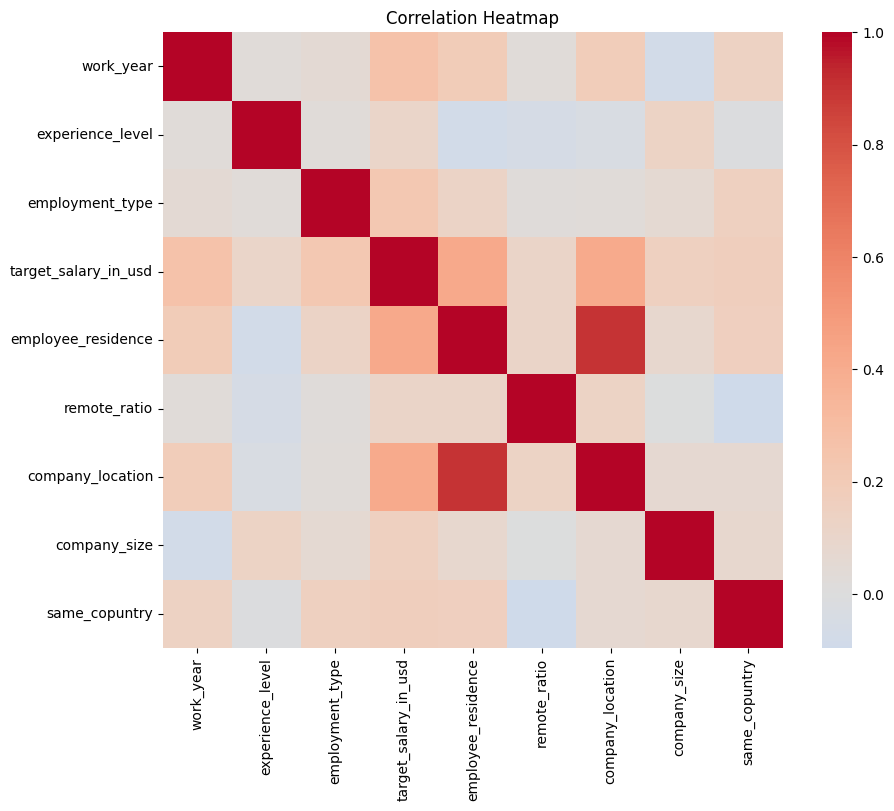

In [82]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
chart_path = "../charts/correlation_heatmap.png"
plt.savefig(chart_path)
plt.show()

In [72]:
def evaluate_regression(model_name, y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)
  return {
      'model': model_name,
      'mae': mae,
      'mse': mse,
      'rmse': rmse,
      'r2': r2
  }



In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   work_year             607 non-null    int64  
 1   experience_level      607 non-null    int64  
 2   employment_type       607 non-null    int64  
 3   job_title             607 non-null    object 
 4   target_salary_in_usd  607 non-null    float64
 5   employee_residence    607 non-null    int64  
 6   remote_ratio          607 non-null    int64  
 7   company_location      607 non-null    int64  
 8   company_size          607 non-null    int64  
 9   same_copuntry         607 non-null    int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 47.6+ KB


In [74]:
# cols = ["experience_level","employment_type","salary_currency", "job_title","company_size"]

# for col in cols:
#     df[col] = df[col].astype("category")

df['job_title'] = df['job_title'].astype('category')
df.head()

,work_year,experience_level,employment_type,job_title,target_salary_in_usd,employee_residence,remote_ratio,company_location,company_size,same_copuntry
0,2020,2,2,Data Scientist,11.287705,15,0,15,2,1
1,2020,1,2,Machine Learning Scientist,12.468441,34,0,34,0,1
2,2020,1,2,Big Data Engineer,11.599332,21,2,21,1,1
3,2020,2,2,Product Data Analyst,9.903538,24,0,24,0,1
4,2020,1,2,Machine Learning Engineer,11.918397,57,2,57,2,1


In [75]:
X= df.drop(columns=["target_salary_in_usd"])
y= df["target_salary_in_usd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
def objective(trial):
    params = {
    "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
    "max_depth": trial.suggest_int("max_depth", 3, 10),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
    "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
    "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",'enable_categorical':True
    }
    

    model = xgboost.XGBRegressor(**params)
    model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))
        

    
    
    return rmse

In [ ]:

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=700)

print("Best trial params: ", study.best_trial.params)
print("Best trial rmse: ", study.best_value)




In [78]:


xgb_reg = xgboost.XGBRegressor(n_estimators=842, max_depth=10, learning_rate=0.2955889510393504, subsample=0.5455277734063878, colsample_bytree=0.9474940046791149, min_child_weight=6, gamma=0.7960293790395987, reg_alpha=0.042097961124780175, reg_lambda=3.0888504559226737, random_state=42, n_jobs=-1, tree_method='hist', enable_categorical=True)
xgb_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)
xgb_metrics = evaluate_regression("XGBoost", y_test, xgb_pred)
print(xgb_metrics)

joblib.dump(xgb_reg, "../model/xgb_model.joblib")


{'model': 'XGBoost', 'mae': 0.3219048937699233, 'mse': 0.2613375354107637, 'rmse': np.float64(0.5112118302726999), 'r2': 0.6284114058072474}


['../model/xgb_model.joblib']

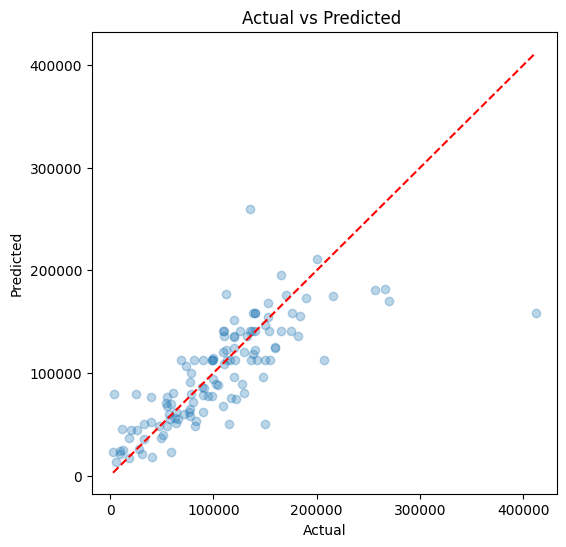

In [79]:

plt.figure(figsize=(6, 6))
plt.scatter(np.expm1(y_test), np.expm1(xgb_pred), alpha=0.3)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted ')
min_v = min(np.expm1(y_test).min(), np.expm1(xgb_pred).min())
max_v = max(np.expm1(y_test).max(), np.expm1(xgb_pred).max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--')
chart_path = "../charts/pred_vs_actual.png"
plt.savefig(chart_path)
plt.show()

In [ ]:
s_reg= joblib.load("../model/xgb_model.joblib")
s_reg.predict(X_test)
s_reg_metrics = evaluate_regression("Loaded XGBoost", y_test, s_reg.predict(X_test))
print(s_reg_metrics)

{'model': 'Loaded XGBoost', 'mae': 0.3219048937699233, 'mse': 0.2613375354107637, 'rmse': np.float64(0.5112118302726999), 'r2': 0.6284114058072474}


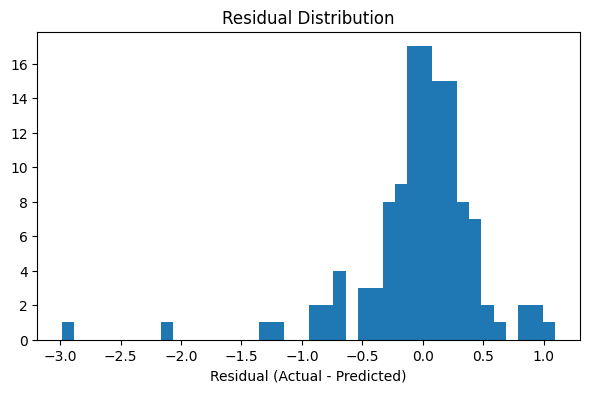

In [81]:
residuals = y_test - xgb_pred
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40)
plt.title('Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
chart_path = "../charts/residual_distribution.png"
plt.savefig(chart_path)
plt.show()

In [ ]:
X_test["predicted_salary"] =np.expm1(xgb_pred)
X_test["actual_salary"] = np.expm1(y_test)
X_test['experience_level']= X_test['experience_level'].map({0: "EN", 1: "SE", 2: "MI", 3: "EX"})
X_test['employment_type'] = X_test['employment_type'].map({0: "FL", 1: "PT", 2: "FT", 3: "CT"})
X_test['same_copuntry'] = X_test['same_copuntry'].map({0: "Different Country", 1: "Same Country"})
X_test['company_size'] = X_test['company_size'].map({0: "S", 1: "M", 2: "L", 3: "X"})
X_test['company_location']= X_test['company_location'].map({i: encoder.inverse_transform([i])[0] for i in X_test['company_location'].unique()})
X_test['employee_residence']= X_test['employee_residence'].map({i: encoder.inverse_transform([i])[0] for i in X_test['employee_residence'].unique()})
X_test.head(100).sort_values(by="actual_salary", ascending=False)

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,same_copuntry,predicted_salary,actual_salary
63,2020,SE,FT,Data Scientist,US,3,US,L,Same Country,158827.484375,412000.0
78,2021,MI,CT,ML Engineer,US,3,US,L,Same Country,170493.812500,270000.0
231,2021,SE,FT,ML Engineer,US,3,US,S,Same Country,181124.765625,256000.0
398,2022,SE,FT,Data Scientist,US,3,US,L,Same Country,175270.750000,215300.0
542,2022,MI,FT,Data Engineer,US,0,US,M,Same Country,112697.898438,206699.0
...,...,...,...,...,...,...,...,...,...,...,...
521,2022,EN,FT,Computer Vision Engineer,PT,3,LU,M,Different Country,23536.451172,10000.0
196,2021,EN,FT,BI Data Analyst,KE,3,KE,S,Same Country,20957.833984,9272.0
77,2021,MI,PT,3D Computer Vision Researcher,IN,2,IN,M,Same Country,13772.232422,5409.0
238,2021,EN,FT,Data Scientist,VN,0,VN,M,Same Country,79074.484375,4000.0
